<a href="https://colab.research.google.com/github/alexfergh2025-ops/TAREA_DesviacionEstatandar/blob/main/TAREA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TAREA: Contexto En un proyecto de desarrollo ágil, el equipo quiere analizar si la cantidad de bugs detectados durante el cierre de los últimos 20 sprints muestra estabilidad o si existen problemas fluctuantes de calidad.
Datos obtenidos (bugs por sprint): 5, 7, 12, 8, 6, 15, 22, 10, 4, 5, 18, 14, 9, 7, 25, 12, 6, 5, 8, 4

Tareas

Determinar el rango en la cantidad de bugs.
Calcular la varianza y explicar si existe dispersión significativa.
Obtener la desviación estándar.

Interpretar:

¿El proceso de desarrollo está siendo consistente?
¿Hubo sprints anómalos que requieren investigación?
¿La desviación estándar indica un riesgo para la calidad del software?

In [30]:
# IMPORTAR  LIBRERIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Datos de bugs por sprint
bugs_por_sprint = pd.Series([5, 7, 12, 8, 6, 15, 22, 10, 4, 5, 18, 14, 9, 7, 25, 12, 6, 5, 8, 4])

print("Datos de bugs por sprint:")
print(bugs_por_sprint)

Datos de bugs por sprint:
0      5
1      7
2     12
3      8
4      6
5     15
6     22
7     10
8      4
9      5
10    18
11    14
12     9
13     7
14    25
15    12
16     6
17     5
18     8
19     4
dtype: int64


In [38]:
# Calcular las medidas de tendencia central
media_bugs = bugs_por_sprint.mean()
mediana_bugs = bugs_por_sprint.median()
moda_bugs = bugs_por_sprint.mode()

print(f"Medidas estadísticas para bugs por sprint:")
print(f"Media: {media_bugs:.2f}")
print(f"Mediana: {mediana_bugs}")
print(f"Moda: {moda_bugs.to_list()}")

Medidas estadísticas para bugs por sprint:
Media: 10.10
Mediana: 8.0
Moda: [5]


In [39]:
# Determinar el rango en la cantidad de bugs
rango_bugs = bugs_por_sprint.max() - bugs_por_sprint.min()
print(f"Rango en la cantidad de bugs: {rango_bugs}")

Rango en la cantidad de bugs: 21


In [40]:
# Calcular la varianza y la desviación estándar
varianza_bugs = bugs_por_sprint.var()
desviacion_estandar_bugs = bugs_por_sprint.std()

print(f"Varianza en la cantidad de bugs: {varianza_bugs:.2f}")
print(f"Desviación estándar en la cantidad de bugs: {desviacion_estandar_bugs:.2f}")


Varianza en la cantidad de bugs: 36.20
Desviación estándar en la cantidad de bugs: 6.02


EXPLICACION:
Sí, existe una dispersión significativa y es considerada ALTA.

Una desviación estándar de 6.02 bugs es considerablemente alta en relación con la media de bugs (que es 10.10). Esto indica que la cantidad de bugs detectados por sprint fluctúa mucho, lo que sugiere una falta de consistencia en el proceso de desarrollo. Cuanto mayor sea la desviación estándar, mayor es la variabilidad entre los sprints.

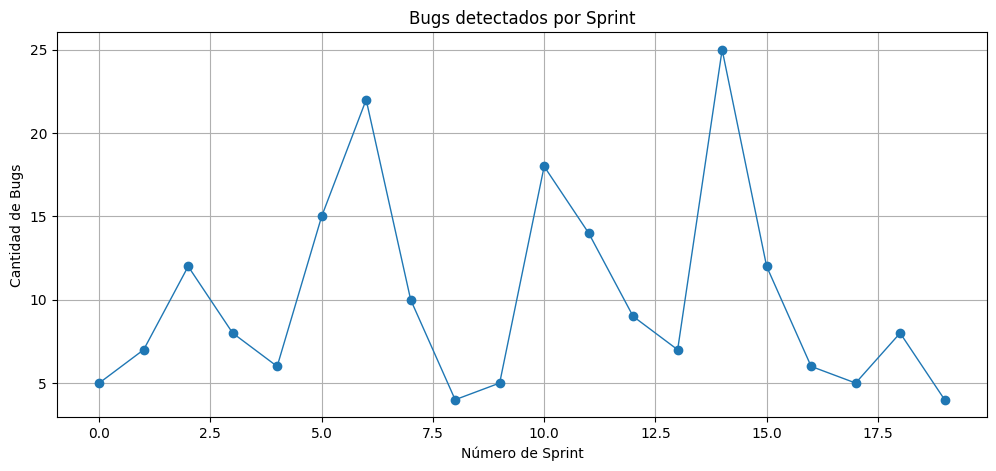

In [41]:
# Gráfico de línea de bugs por sprint
plt.figure(figsize=(12,5))
plt.plot(bugs_por_sprint, linewidth=1, marker='o')
plt.title('Bugs detectados por Sprint')
plt.xlabel('Número de Sprint')
plt.ylabel('Cantidad de Bugs')
plt.grid(True)
plt.show()

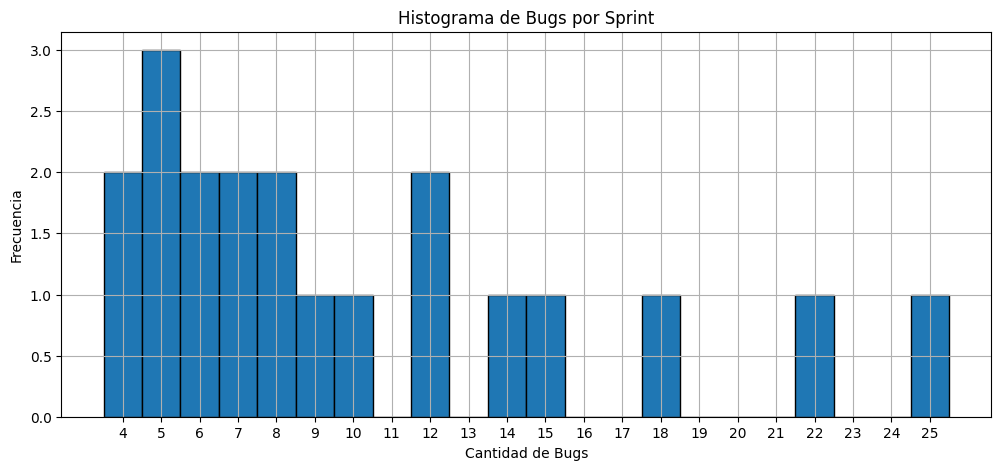

In [42]:
# Histograma de bugs por sprint
plt.figure(figsize=(12,5))
plt.hist(bugs_por_sprint, bins=range(min(bugs_por_sprint), max(bugs_por_sprint) + 2), edgecolor='black', align='left')
plt.title('Histograma de Bugs por Sprint')
plt.xlabel('Cantidad de Bugs')
plt.ylabel('Frecuencia')
plt.xticks(range(min(bugs_por_sprint), max(bugs_por_sprint) + 1))
plt.grid(True)
plt.show()

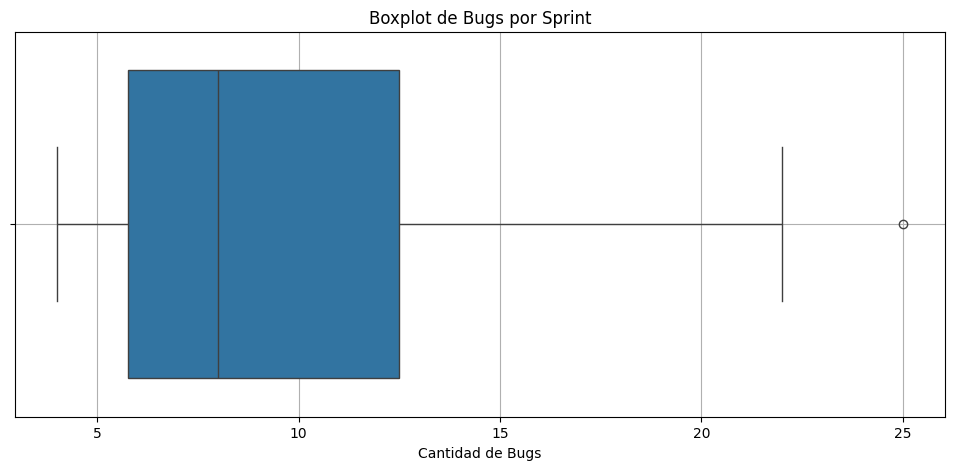

In [43]:
# Boxplot de bugs por sprint
plt.figure(figsize=(12,5))
sns.boxplot(x=bugs_por_sprint)
plt.title('Boxplot de Bugs por Sprint')
plt.xlabel('Cantidad de Bugs')
plt.grid(True)
plt.show()

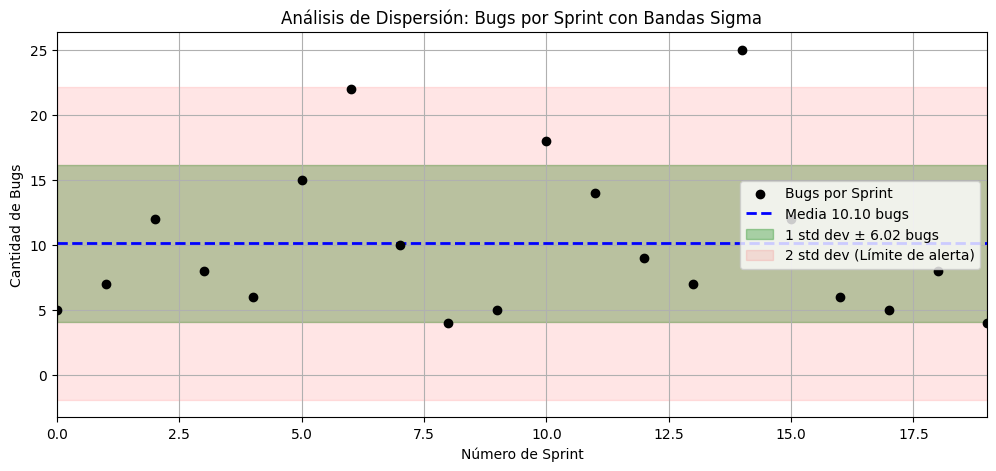

In [44]:
# Análisis de dispersión: Bugs por sprint con bandas sigma
plt.figure(figsize=(12,5))
plt.scatter(bugs_por_sprint.index, bugs_por_sprint, color='black', zorder=5, label="Bugs por Sprint")
plt.axhline(y=media_bugs, color='blue', linestyle='--', label=f"Media {media_bugs:.2f} bugs", linewidth=2)
plt.fill_between(bugs_por_sprint.index, media_bugs - desviacion_estandar_bugs, media_bugs + desviacion_estandar_bugs, color ='green', alpha=0.3, label = f"1 std dev \u00B1 {desviacion_estandar_bugs:.2f} bugs")
plt.fill_between(bugs_por_sprint.index, media_bugs - 2*desviacion_estandar_bugs, media_bugs + 2*desviacion_estandar_bugs, color ='red', alpha=0.1, label = f"2 std dev (Límite de alerta)")
plt.title('Análisis de Dispersión: Bugs por Sprint con Bandas Sigma')
plt.xlabel('Número de Sprint')
plt.ylabel('Cantidad de Bugs')
plt.xlim(bugs_por_sprint.index.min(), bugs_por_sprint.index.max())
plt.legend()
plt.grid(True)
plt.show()

Preguntas:

¿El proceso de desarrollo está siendo consistente? No es consistente. La alta desviación estándar (6.02) y el rango (21) muestran mucha variabilidad en los bugs por sprint.


¿Hubo sprints anómalos que requieren investigación? Sí. Los sprints con 22 y 25 bugs son anomalías que necesitan ser investigadas, ya que se desvían significativamente de la media.


¿La desviación estándar indica un riesgo para la calidad del software? Sí, indica un riesgo moderado a alto. La alta variabilidad en los bugs hace que la calidad sea impredecible, lo que es un riesgo para la planificación y la estabilidad del software.